# Online Model Analysis — Memory Window Tuning

This notebook adds a **memory window** parameter `K` (number of past turns to condition on) to the teacher-forced Bayesian model.
Instead of accumulating all past observations, the model only uses the most recent `K` turns for belief updating.

We jointly tune `(τ, ε, K)` to maximize combo Pearson r.

In [29]:
import sys
from collections import defaultdict
from itertools import product
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from memo import memo
from scipy.stats import pearsonr

# Add simulation/ to path for memo-based inference
PROJECT_DIR = Path(".").resolve().parent
sys.path.insert(0, str(PROJECT_DIR / "simulation"))
sys.path.insert(0, str(PROJECT_DIR / "analysis"))

from online_model_sim import (
    canonical_combo, get_canonical_combos,
    utility_based_prior, uniform_prior, _preferred_action,
    softmax_role_dist, game_step,
    load_team_rounds, combo_marginal, compute_pearson,
    ALL_ROLE_COMBOS, ROLE_NAMES, ROLE_CHAR_TO_IDX, GAME_ROLE_TO_IDX,
    ROLE_COLORS, F, T, M, ATTACK, DEFEND, HEAL,
    EPSILON, MAX_STAGES, TURNS_PER_STAGE, TAU,
    ROLE_COMBO_TO_ENV_NUM,
)

%matplotlib inline

## Configuration

In [30]:
# === Paths ===
SCRIPT_DIR = Path(".").resolve()
DEFAULT_DATA_DIR = PROJECT_DIR / "bayesian-role-specialization-2026-03-06-09-54-19"
OUTPUT_DIR = SCRIPT_DIR / "figures" / "model_comparison_online_memory"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Data directories
data_dirs = [str(DEFAULT_DATA_DIR)]

print(f"Data dirs: {data_dirs}")

Data dirs: ['/Users/bhavyesh/Desktop/bayesian-role-specialization/computational_model/bayesian-role-specialization-2026-03-06-09-54-19']


## Memory-Specific Model Extension

In [31]:
# --- Memo-based Bayesian inference (from simulation/inference.py) ---

ROLES = [0, 1, 2]
ACTIONS = [0, 1, 2]


@jax.jit
def _get_element(array, i0, i1, i2):
    return array[i0, i1, i2]


def _role_policy(role, action, intent, team_hp, team_max_hp, epsilon):
    """P(action | role, state). Parameterized version of pi.choose_policy."""
    fighter = jnp.where(action == ATTACK, 1.0 - epsilon, epsilon / 2.0)
    tank_pref = jnp.where(intent == 1, DEFEND, ATTACK)
    tank = jnp.where(action == tank_pref, 1.0 - epsilon, epsilon / 2.0)
    medic_pref = jnp.where(team_hp < team_max_hp, HEAL, ATTACK)
    medic = jnp.where(action == medic_pref, 1.0 - epsilon, epsilon / 2.0)
    return jnp.where(role == F, fighter, jnp.where(role == T, tank, medic))


@memo
def role_inference[r0: ROLES, r1: ROLES, r2: ROLES](
    role_prior: ..., obs_a0, obs_a1, obs_a2, intent, team_hp, team_max_hp, epsilon
):
    """Infers P(roles | observations) using memo-lang Bayesian inference."""
    observer: knows(r0, r1, r2)
    observer: thinks[
        team: assigned(r0 in ROLES, r1 in ROLES, r2 in ROLES,
                       wpp=_get_element(role_prior, r0, r1, r2)),
        team: chooses(a0 in ACTIONS, wpp=_role_policy(r0, a0, intent, team_hp, team_max_hp, epsilon)),
        team: chooses(a1 in ACTIONS, wpp=_role_policy(r1, a1, intent, team_hp, team_max_hp, epsilon)),
        team: chooses(a2 in ACTIONS, wpp=_role_policy(r2, a2, intent, team_hp, team_max_hp, epsilon))
    ]
    observer: observes_that[team.a0 == obs_a0]
    observer: observes_that[team.a1 == obs_a1]
    observer: observes_that[team.a2 == obs_a2]
    return observer[Pr[r0 == team.r0 and r1 == team.r1 and r2 == team.r2]]


def bayesian_update(prior, actions, intent, team_hp, team_max_hp, epsilon=EPSILON):
    posterior = np.array(role_inference(
        jnp.array(prior), actions[0], actions[1], actions[2],
        intent, team_hp, team_max_hp, epsilon
    ))
    total = posterior.sum()
    if total > 0:
        posterior /= total
    else:
        posterior = np.ones((3, 3, 3)) / 27.0
    return posterior


def compute_posterior_from_history(base_prior, observation_history, epsilon=EPSILON):
    """Recompute posterior from base prior using a list of past observations.
    Each observation is (actions, intent, team_hp, team_max_hp)."""
    posterior = np.copy(base_prior)
    for actions, intent, team_hp, team_max_hp in observation_history:
        posterior = bayesian_update(posterior, actions, intent, team_hp, team_max_hp, epsilon)
    return posterior

## Teacher-Forced Prediction with Memory Window

The key difference: `memory_turns` (K) limits how many past turns of observations are used.
- `K = None` (or very large): use all past turns (original behavior)
- `K = 2`: only condition on the most recent 2 turns (= 1 stage)
- `K = 4`: condition on the most recent 4 turns (= 2 stages)

Implementation: store all observations in a history buffer. Before each prediction,
recompute the posterior from the prior using only the last K observations.

In [32]:
def teacher_forced_predictions(record, tau=TAU, prior_type="utility", epsilon=EPSILON, memory_turns=None):
    """Teacher-forced predictions with optional memory window.
    
    Args:
        memory_turns: Number of past turns to condition on.
            None = all turns (original behavior).
            2 = last 1 stage, 4 = last 2 stages, etc.
    """
    env = record["env_config"]
    values, player_stats = env["values"], env["player_stats"]
    boss_damage = env["boss_damage"]
    team_max_hp, enemy_max_hp = env["team_max_hp"], env["enemy_max_hp"]

    team_hp, enemy_hp = float(team_max_hp), float(enemy_max_hp)
    if prior_type == "uniform":
        base_prior = uniform_prior()
    else:
        base_prior = utility_based_prior(player_stats, tau=tau)
    
    results = []
    turn_idx = 0
    observation_history = []  # list of (actions, intent, team_hp, team_max_hp)

    for human_combo in record["stage_roles"]:
        if turn_idx >= len(record["lds"]) or team_hp <= 0 or enemy_hp <= 0:
            break

        intent = record["lds"][turn_idx]
        thp = int(min(max(0, team_hp), team_max_hp))
        ehp = int(min(max(0, enemy_hp), enemy_max_hp))

        # Compute posterior from windowed history
        if memory_turns is not None:
            windowed = observation_history[-memory_turns:] if memory_turns > 0 else []
            prior = compute_posterior_from_history(base_prior, windowed, epsilon)
        else:
            prior = compute_posterior_from_history(base_prior, observation_history, epsilon)

        per_agent = [softmax_role_dist(i, intent, thp, ehp, prior, values, tau) for i in range(3)]

        predicted_dist = {}
        for r0 in range(3):
            for r1 in range(3):
                for r2 in range(3):
                    combo = ROLE_NAMES[r0] + ROLE_NAMES[r1] + ROLE_NAMES[r2]
                    predicted_dist[combo] = float(per_agent[0][r0] * per_agent[1][r1] * per_agent[2][r2])

        results.append({
            "predicted_dist": predicted_dist,
            "human_combo": human_combo,
            "model_marginal": np.mean(per_agent, axis=0),
        })

        # Advance game with human roles, recording observations
        human_roles = [ROLE_CHAR_TO_IDX[c] for c in human_combo]
        for _ in range(TURNS_PER_STAGE):
            if turn_idx >= len(record["lds"]) or team_hp <= 0 or enemy_hp <= 0:
                break
            intent = record["lds"][turn_idx]
            actions = [_preferred_action(human_roles[i], intent, team_hp, team_max_hp) for i in range(3)]
            observation_history.append((actions, intent, int(team_hp), team_max_hp))
            team_hp, enemy_hp = game_step(intent, team_hp, enemy_hp, actions, player_stats, boss_damage, team_max_hp)
            turn_idx += 1

    return results


def run_all_predictions(records, tau=TAU, prior_type="utility", epsilon=EPSILON, memory_turns=None):
    by_env = defaultdict(list)
    for rec in records:
        by_env[rec["env_id"]].append(rec)

    all_results = {}

    for env_id, env_records in by_env.items():
        stat_profile = env_records[0]["stat_profile"]
        optimal = env_records[0]["optimal_roles"]
        canon_combos = get_canonical_combos(stat_profile)

        stage_predicted = defaultdict(lambda: defaultdict(float))
        stage_human = defaultdict(lambda: defaultdict(int))
        stage_model_marg = defaultdict(lambda: np.zeros(3))
        stage_human_marg = defaultdict(lambda: np.zeros(3))
        stage_counts = defaultdict(int)
        team_predictions = []
        max_stages = 0

        for rec in env_records:
            preds = teacher_forced_predictions(rec, tau=tau, prior_type=prior_type, epsilon=epsilon, memory_turns=memory_turns)
            team_predictions.append(preds)

            for s, pred in enumerate(preds):
                stage_counts[s] += 1
                max_stages = max(max_stages, s + 1)

                for combo, prob in pred["predicted_dist"].items():
                    stage_predicted[s][canonical_combo(combo, stat_profile)] += prob
                stage_human[s][canonical_combo(pred["human_combo"], stat_profile)] += 1

                stage_model_marg[s] += pred["model_marginal"]
                stage_human_marg[s] += combo_marginal(pred["human_combo"])

        predicted_avg, model_marg_avg, human_marg_avg = {}, {}, {}
        for s in range(max_stages):
            n = stage_counts[s]
            if n > 0:
                predicted_avg[s] = {cc: stage_predicted[s].get(cc, 0.0) / n for cc in canon_combos}
                model_marg_avg[s] = stage_model_marg[s] / n
                human_marg_avg[s] = stage_human_marg[s] / n

        all_results[env_id] = {
            "stat_profile": stat_profile,
            "optimal": optimal,
            "canonical_optimal": canonical_combo(optimal, stat_profile),
            "canonical_combos": canon_combos,
            "n_teams": len(env_records),
            "max_stages": max_stages,
            "stage_predicted": predicted_avg,
            "stage_human": dict(stage_human),
            "stage_counts": dict(stage_counts),
            "team_predictions": team_predictions,
            "stage_model_marginal": model_marg_avg,
            "stage_human_marginal": human_marg_avg,
        }

    return all_results

## Plotting

In [33]:
def plot_comparison(all_results, correlations, tau=TAU, epsilon=EPSILON, memory_turns=None, save=False):
    mem_str = f"K={memory_turns}" if memory_turns is not None else "K=all"
    for env_id, data in all_results.items():
        canon_combos = data["canonical_combos"]
        optimal_canon = data["canonical_optimal"]
        max_stages = data["max_stages"]
        stages = list(range(1, max_stages + 1))

        model_probs = {cc: [] for cc in canon_combos}
        human_probs = {cc: [] for cc in canon_combos}
        for s in range(max_stages):
            predicted = data["stage_predicted"].get(s, {})
            human_counts = data["stage_human"].get(s, {})
            n = data["stage_counts"].get(s, 0)
            for cc in canon_combos:
                model_probs[cc].append(predicted.get(cc, 0.0))
                human_probs[cc].append(human_counts.get(cc, 0) / n if n > 0 else 0)

        played = [
            cc for cc in canon_combos
            if cc == optimal_canon
            or any(p > 0 for p in human_probs[cc])
            or any(p > 0.02 for p in model_probs[cc])
        ]

        fig, axes = plt.subplots(1, 3, figsize=(20, 5))

        for cc in played:
            is_opt = cc == optimal_canon
            kw = dict(linewidth=2.5 if is_opt else 1.2, markersize=8 if is_opt else 4,
                       label=f"{cc} (optimal)" if is_opt else cc)
            if is_opt:
                kw["color"] = "red"
            axes[0].plot(stages, human_probs[cc], "o-", **kw)
            axes[1].plot(stages, model_probs[cc], "o-", **kw)

        for role_idx, role_name in ROLE_NAMES.items():
            h_vals = [data["stage_human_marginal"].get(s, np.zeros(3))[role_idx] for s in range(max_stages)]
            m_vals = [data["stage_model_marginal"].get(s, np.zeros(3))[role_idx] for s in range(max_stages)]
            color = ROLE_COLORS[role_name]
            axes[2].plot(stages, h_vals, "o-", color=color, linewidth=2, label=f"{role_name} human")
            axes[2].plot(stages, m_vals, "s--", color=color, linewidth=2, alpha=0.7, label=f"{role_name} model")

        env_corr = correlations.get(env_id, {})
        combo_r = env_corr.get("combo", {}).get("r", float("nan"))
        marg_r = env_corr.get("marginal", {}).get("r", float("nan"))

        for ax, title in [(axes[0], f"Human ({data['n_teams']} teams)"),
                          (axes[1], f"Model (τ={tau}, ε={epsilon:.4g}, {mem_str})")]:
            ax.set_xlabel("Stage")
            ax.set_ylabel("P(combo)")
            ax.set_title(title)
            ax.set_xticks(stages)
            ax.set_ylim(-0.05, 1.05)
            ax.legend(fontsize=7)
            ax.grid(True, alpha=0.3)

        axes[2].set_xlabel("Stage")
        axes[2].set_ylabel("P(role)")
        axes[2].set_title(f"Marginals (r={marg_r:.3f})" if not np.isnan(marg_r) else "Marginals")
        axes[2].set_xticks(stages)
        axes[2].set_ylim(-0.05, 1.05)
        axes[2].legend(fontsize=7)
        axes[2].grid(True, alpha=0.3)

        r_str = f"combo r={combo_r:.3f}" if not np.isnan(combo_r) else "combo r=N/A"
        fig.suptitle(
            f"{env_id} | {data['stat_profile']} | Optimal: {optimal_canon} | {r_str}",
            fontsize=12, fontweight="bold",
        )
        plt.tight_layout()

        if save:
            role_combo = data["optimal"]
            env_num = ROLE_COMBO_TO_ENV_NUM.get(role_combo, "")
            folder_name = f"{env_num}_{env_id}" if env_num else env_id
            env_dir = OUTPUT_DIR / folder_name
            env_dir.mkdir(parents=True, exist_ok=True)
            fig.savefig(env_dir / f"online_{env_id}.png", dpi=150, bbox_inches="tight")

        plt.show()

        # Bar chart
        n_stages = max_stages
        fig_bar, axes_bar = plt.subplots(1, n_stages, figsize=(5 * n_stages, 5), sharey=True)
        if n_stages == 1:
            axes_bar = [axes_bar]

        bar_width = 0.35
        for s in range(n_stages):
            ax = axes_bar[s]
            h_vals = [human_probs[cc][s] for cc in played]
            m_vals = [model_probs[cc][s] for cc in played]
            x = np.arange(len(played))

            ax.bar(x - bar_width / 2, h_vals, bar_width, label="Human", color="#3498db", alpha=0.8)
            ax.bar(x + bar_width / 2, m_vals, bar_width, label="Model", color="#e74c3c", alpha=0.8)

            for i, cc in enumerate(played):
                if cc == optimal_canon:
                    ax.bar(x[i] - bar_width / 2, h_vals[i], bar_width, color="#3498db", edgecolor="gold", linewidth=2.5)
                    ax.bar(x[i] + bar_width / 2, m_vals[i], bar_width, color="#e74c3c", edgecolor="gold", linewidth=2.5)

            ax.set_xlabel("Role combo")
            ax.set_title(f"Stage {s + 1}")
            ax.set_xticks(x)
            ax.set_xticklabels([f"{cc}*" if cc == optimal_canon else cc for cc in played],
                               rotation=45, ha="right", fontsize=7)
            ax.set_ylim(0, 1.05)
            ax.grid(True, alpha=0.3, axis="y")
            if s == 0:
                ax.set_ylabel("P(combo)")
                ax.legend(fontsize=8)

        r_str = f"combo r={combo_r:.3f}" if not np.isnan(combo_r) else "combo r=N/A"
        fig_bar.suptitle(
            f"{env_id} | Optimal: {optimal_canon}* | {r_str} | τ={tau}, ε={epsilon:.4g}, {mem_str}",
            fontsize=12, fontweight="bold",
        )
        plt.tight_layout()

        if save:
            fig_bar.savefig(env_dir / f"online_{env_id}_bars.png", dpi=150, bbox_inches="tight")

        plt.show()

## 1. Load Data

In [34]:
records = load_team_rounds(data_dirs=data_dirs)
n_envs = len(set(r["env_id"] for r in records))
print(f"Loaded {len(records)} team-rounds across {n_envs} envs")

Loaded 24 team-rounds across 6 envs


## 2. Fine-Tune τ, ε, and K (memory window)

For each value of K (memory turns), run a 2D grid search over (τ, ε), then pick the best (τ, ε, K) triple.

In [35]:
# Fine-tuning settings
prior_type = "utility"
metric = "combo_r"
tau_min, tau_max, tau_steps = 0.1, 10.0, 30
eps_min, eps_max, eps_steps = 0.001, 0.2, 15

# Memory window: number of past turns to condition on (0 to 10)
memory_values = list(range(0, 11))

In [36]:
def evaluate(records, tau, prior_type="utility", epsilon=EPSILON, memory_turns=None):
    """Run model at given (τ, ε, K) and return fit metrics."""
    results = run_all_predictions(records, tau=tau, prior_type=prior_type, epsilon=epsilon, memory_turns=memory_turns)
    correlations = compute_pearson(results)

    g = correlations.get("__global__", {})
    combo_r = g.get("combo", {}).get("r", float("nan"))
    marg_r = g.get("marginal", {}).get("r", float("nan"))

    return {
        "tau": tau,
        "epsilon": epsilon,
        "memory_turns": memory_turns,
        "combo_r": combo_r,
        "marg_r": marg_r,
        "correlations": correlations,
    }


def grid_search_3d(records, tau_values, epsilon_values, memory_values, prior_type="utility"):
    results = []
    total = len(tau_values) * len(epsilon_values) * len(memory_values)
    i = 0
    for K in memory_values:
        K_str = f"K={K}" if K is not None else "K=all"
        print(f"\n  --- {K_str} ---")
        for t in tau_values:
            for eps in epsilon_values:
                i += 1
                res = evaluate(records, t, prior_type=prior_type, epsilon=eps, memory_turns=K)
                results.append(res)
                if i % 100 == 0 or i == total:
                    print(f"  [{i}/{total}] τ={t:.2f} ε={eps:.4f} {K_str} combo_r={res['combo_r']:.4f}", flush=True)
    return results


def pick_best(results, metric="combo_r"):
    return max(results, key=lambda r: r["combo_r"] if not np.isnan(r["combo_r"]) else -np.inf)

In [37]:
# Coarse 3D grid search
tau_values = np.linspace(tau_min, tau_max, tau_steps)
eps_values = np.geomspace(eps_min, eps_max, eps_steps)
n_total = tau_steps * eps_steps * len(memory_values)
print(f"3D grid: {tau_steps} τ x {eps_steps} ε x {len(memory_values)} K = {n_total} points")
print(f"  τ in [{tau_min}, {tau_max}], ε in [{eps_min}, {eps_max}]")
print(f"  K in {memory_values}")
print(f"  prior = {prior_type}")

sweep_results = grid_search_3d(records, tau_values, eps_values, memory_values, prior_type=prior_type)
best_result = pick_best(sweep_results)
K_str = f"K={best_result['memory_turns']}" if best_result['memory_turns'] is not None else "K=all"
print(f"\nCoarse best: τ={best_result['tau']:.4f} ε={best_result['epsilon']:.6f} {K_str} "
      f"combo_r={best_result['combo_r']:.4f}")

3D grid: 30 τ x 15 ε x 11 K = 4950 points
  τ in [0.1, 10.0], ε in [0.001, 0.2]
  K in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
  prior = utility

  --- K=0 ---
  [100/4950] τ=2.15 ε=0.0301 K=0 combo_r=0.2025
  [200/4950] τ=4.54 ε=0.0045 K=0 combo_r=0.2100
  [300/4950] τ=6.59 ε=0.2000 K=0 combo_r=0.2220
  [400/4950] τ=8.98 ε=0.0301 K=0 combo_r=0.2337

  --- K=1 ---
  [500/4950] τ=1.12 ε=0.0045 K=1 combo_r=0.2055
  [600/4950] τ=3.17 ε=0.2000 K=1 combo_r=0.2208
  [700/4950] τ=5.56 ε=0.0301 K=1 combo_r=0.2072
  [800/4950] τ=7.95 ε=0.0045 K=1 combo_r=0.2061
  [900/4950] τ=10.00 ε=0.2000 K=1 combo_r=0.2298

  --- K=2 ---
  [1000/4950] τ=2.15 ε=0.0301 K=2 combo_r=0.1829
  [1100/4950] τ=4.54 ε=0.0045 K=2 combo_r=0.1917
  [1200/4950] τ=6.59 ε=0.2000 K=2 combo_r=0.2147
  [1300/4950] τ=8.98 ε=0.0301 K=2 combo_r=0.2046

  --- K=3 ---
  [1400/4950] τ=1.12 ε=0.0045 K=3 combo_r=0.1988
  [1500/4950] τ=3.17 ε=0.2000 K=3 combo_r=0.2051
  [1600/4950] τ=5.56 ε=0.0301 K=3 combo_r=0.2003
  [1700/4950] τ=7.95 ε=0

In [38]:
# Refine around best (τ, ε) at best K
tau_step = (tau_max - tau_min) / tau_steps
eps_ratio = (eps_max / eps_min) ** (1.0 / eps_steps)
best_K = best_result["memory_turns"]

fine_taus = np.linspace(
    max(tau_min, best_result["tau"] - tau_step),
    min(tau_max, best_result["tau"] + tau_step),
    20,
)
fine_eps = np.geomspace(
    max(eps_min, best_result["epsilon"] / eps_ratio),
    min(eps_max, best_result["epsilon"] * eps_ratio),
    20,
)

K_str = f"K={best_K}" if best_K is not None else "K=all"
print(f"Refining around τ={best_result['tau']:.4f} ε={best_result['epsilon']:.4f} {K_str} ...")
refined = grid_search_3d(records, fine_taus, fine_eps, [best_K], prior_type=prior_type)
sweep_results.extend(refined)
best_result = pick_best(sweep_results)
K_str = f"K={best_result['memory_turns']}" if best_result['memory_turns'] is not None else "K=all"
print(f"\nRefined best: τ={best_result['tau']:.4f} ε={best_result['epsilon']:.6f} {K_str} "
      f"combo_r={best_result['combo_r']:.4f}")

Refining around τ=0.7828 ε=0.2000 K=1 ...

  --- K=1 ---
  [100/400] τ=0.59 ε=0.2000 K=1 combo_r=0.2304
  [200/400] τ=0.77 ε=0.2000 K=1 combo_r=0.2407
  [300/400] τ=0.94 ε=0.2000 K=1 combo_r=0.2403
  [400/400] τ=1.11 ε=0.2000 K=1 combo_r=0.2284

Refined best: τ=0.8696 ε=0.200000 K=1 combo_r=0.2419


## 3. Results Summary

In [39]:
# Best per K
print("Best combo_r per memory window K:")
print(f"  {'K':<8} {'τ':>8} {'ε':>10} {'combo_r':>10} {'marg_r':>10}")
print(f"  {'-'*48}")
for K in memory_values:
    K_results = [r for r in sweep_results if r["memory_turns"] == K]
    if K_results:
        best_K = pick_best(K_results)
        K_label = f"{K}" if K is not None else "all"
        print(f"  {K_label:<8} {best_K['tau']:>8.4f} {best_K['epsilon']:>10.6f} "
              f"{best_K['combo_r']:>10.4f} {best_K['marg_r']:>10.4f}")

# Overall best
K_str = f"K={best_result['memory_turns']}" if best_result['memory_turns'] is not None else "K=all"
print(f"\n{'='*60}")
print(f"OVERALL BEST: τ={best_result['tau']:.4f}, ε={best_result['epsilon']:.6f}, {K_str}")
print(f"  combo_r = {best_result['combo_r']:.4f}")
print(f"  marg_r  = {best_result['marg_r']:.4f}")
print(f"{'='*60}")

# Baseline comparison
baseline = evaluate(records, 1.0, prior_type=prior_type)
print(f"\nComparison with defaults (τ=1.0, ε=1e-10, K=all):")
print(f"  {'metric':<10} {'default':>10} {'best':>10} {'delta':>10}")
print(f"  {'combo_r':<10} {baseline['combo_r']:>10.4f} {best_result['combo_r']:>10.4f} {best_result['combo_r'] - baseline['combo_r']:>+10.4f}")
print(f"  {'marg_r':<10} {baseline['marg_r']:>10.4f} {best_result['marg_r']:>10.4f} {best_result['marg_r'] - baseline['marg_r']:>+10.4f}")

# Per-environment
print(f"\nPer-environment correlations at best:")
best_corrs = best_result["correlations"]
for env_id in sorted(k for k in best_corrs if k != "__global__"):
    c = best_corrs[env_id]
    combo = c.get("combo", {})
    marg = c.get("marginal", {})
    parts = []
    if combo:
        parts.append(f"combo_r={combo['r']:.4f}")
    if marg:
        parts.append(f"marg_r={marg['r']:.4f}")
    print(f"  {env_id}: {', '.join(parts)}")
g = best_corrs.get("__global__", {})
if g:
    print(f"  GLOBAL: combo_r={g.get('combo', {}).get('r', float('nan')):.4f}, "
          f"marg_r={g.get('marginal', {}).get('r', float('nan')):.4f}")

Best combo_r per memory window K:
  K               τ          ε    combo_r     marg_r
  ------------------------------------------------
  0         10.0000   0.001000     0.2368     0.3384
  1          0.8696   0.200000     0.2419     0.4040
  2          0.7828   0.200000     0.2380     0.3915
  3          0.7828   0.030146     0.2253     0.3941
  4          8.2931   0.200000     0.2330     0.3044
  5          0.7828   0.020648     0.2273     0.3816
  6          0.7828   0.020648     0.2318     0.4065
  7          0.7828   0.020648     0.2150     0.4149
  8          0.7828   0.020648     0.2160     0.4157
  9          0.7828   0.020648     0.2160     0.4157
  10         0.7828   0.020648     0.2160     0.4157

OVERALL BEST: τ=0.8696, ε=0.200000, K=1
  combo_r = 0.2419
  marg_r  = 0.4040

Comparison with defaults (τ=1.0, ε=1e-10, K=all):
  metric        default       best      delta
  combo_r        0.2220     0.2419    +0.0199
  marg_r         0.4414     0.4040    -0.0374

Per-enviro

## 4. Plots with Best Parameters

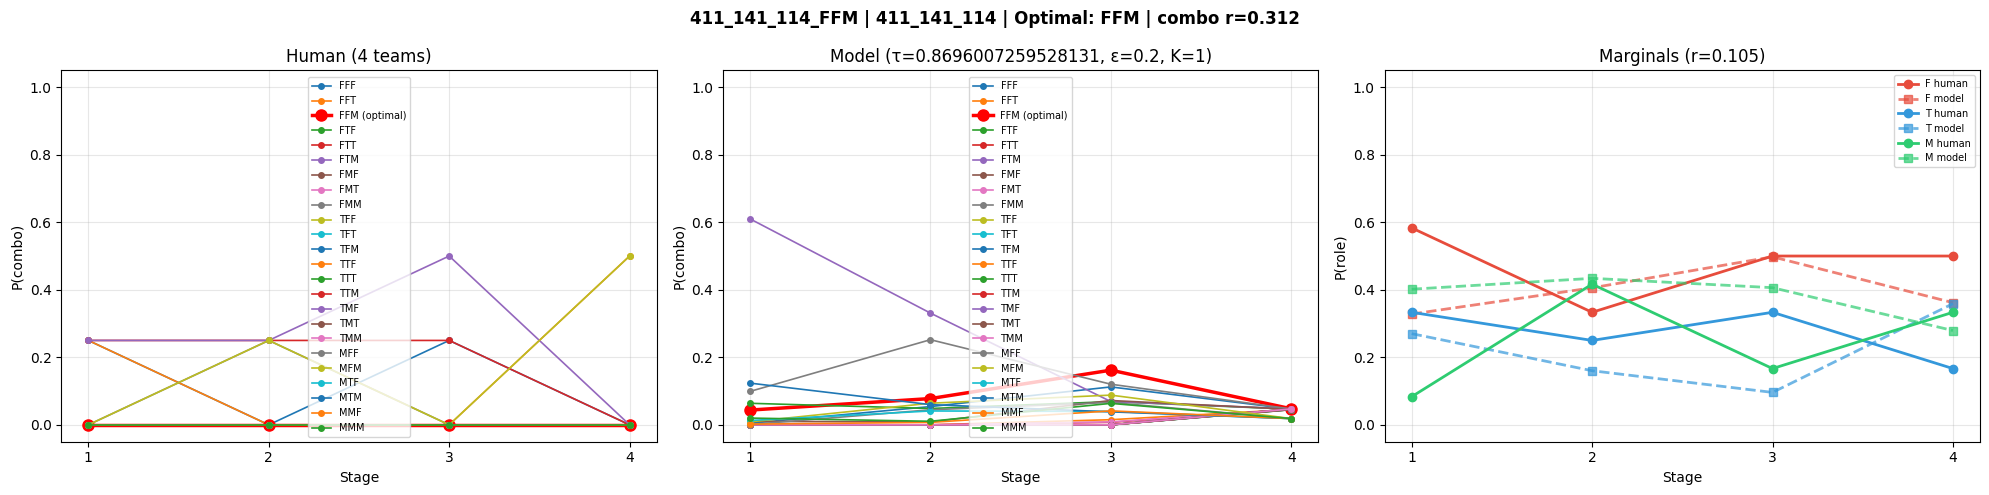

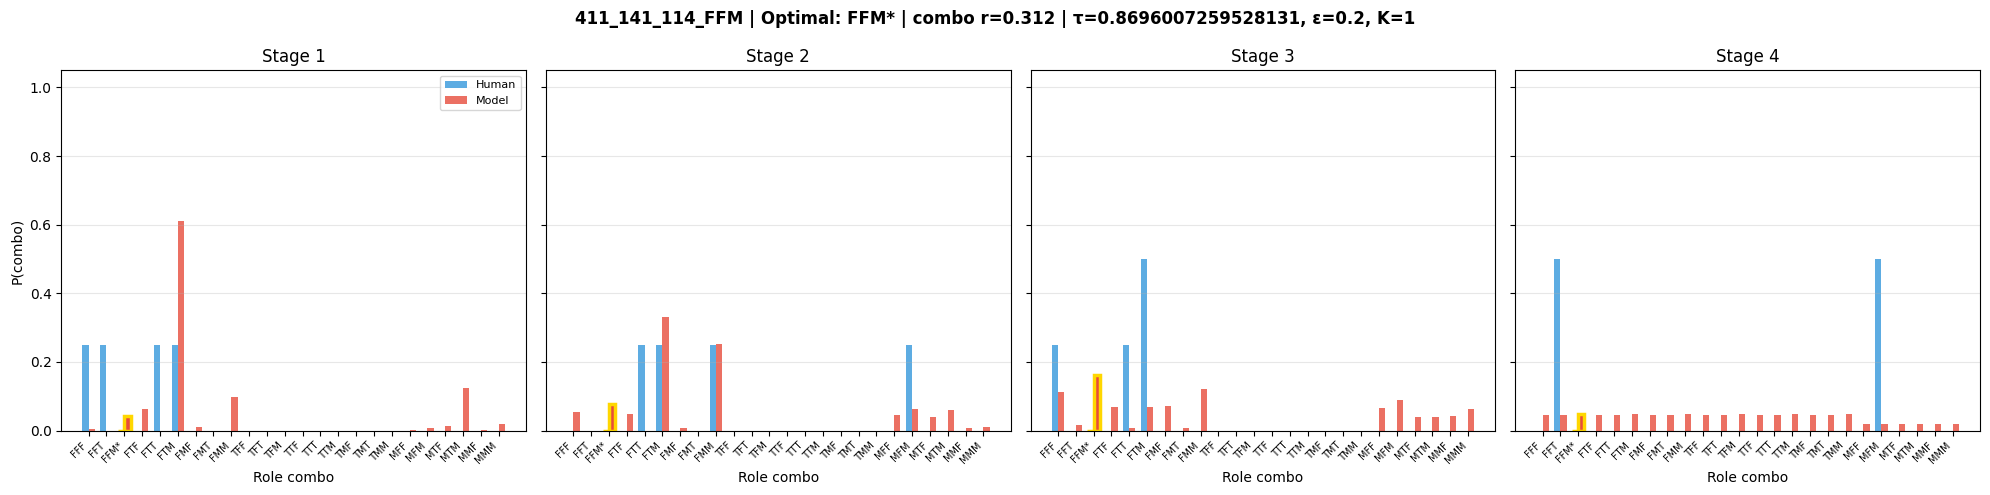

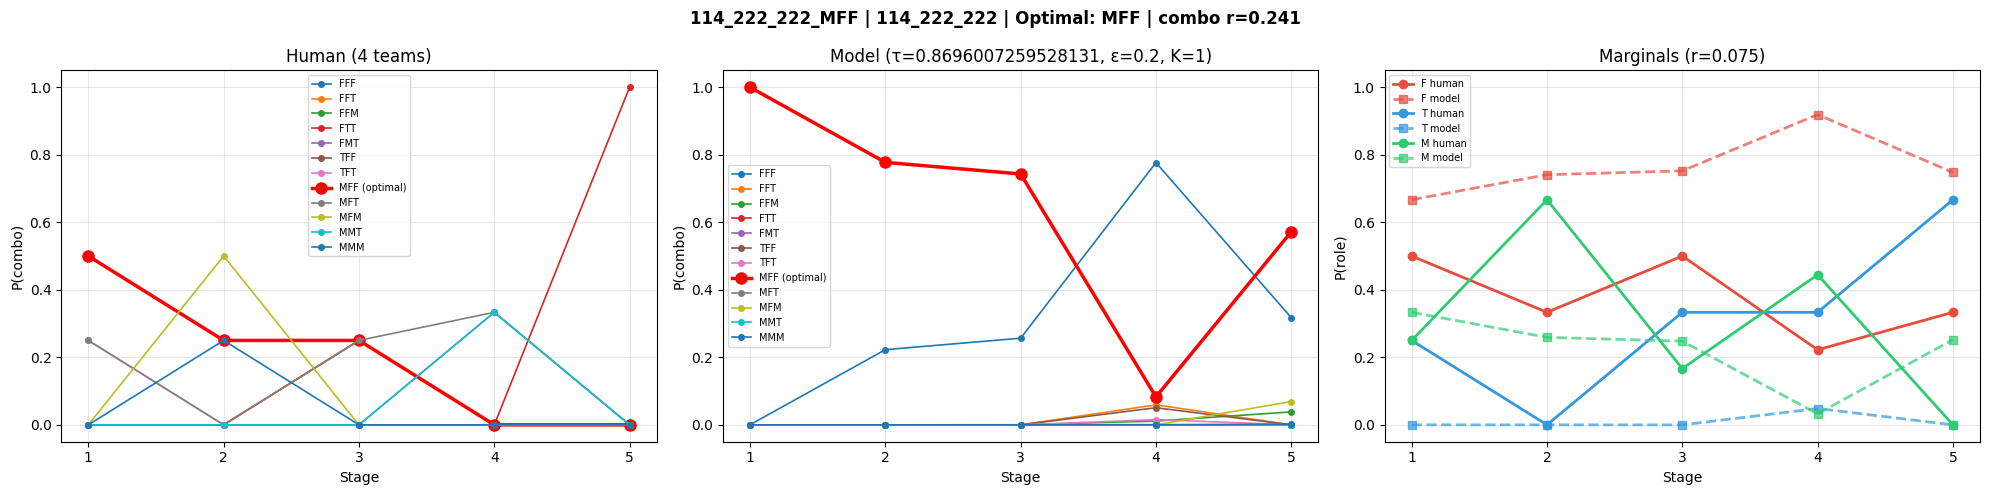

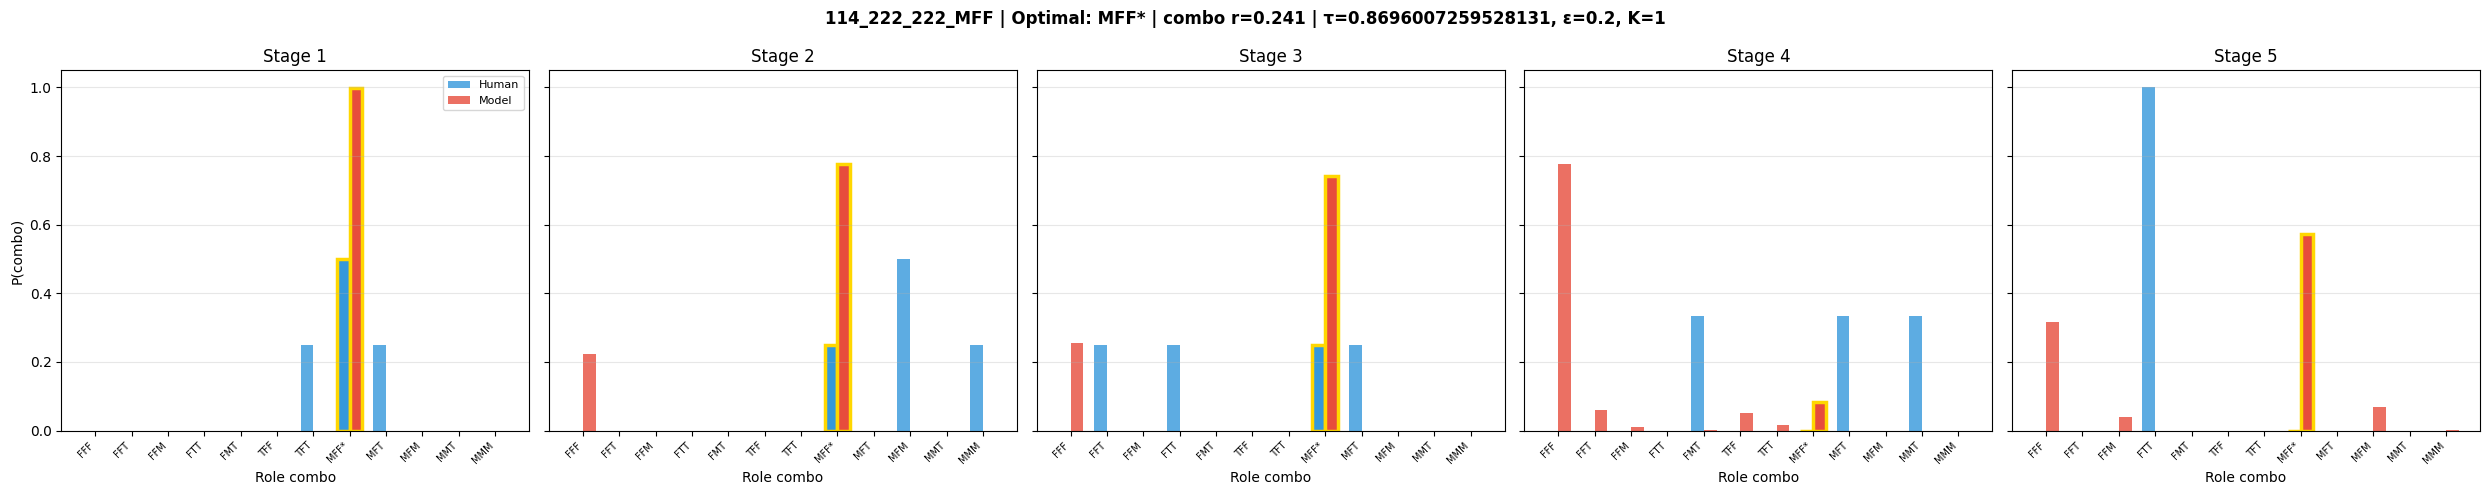

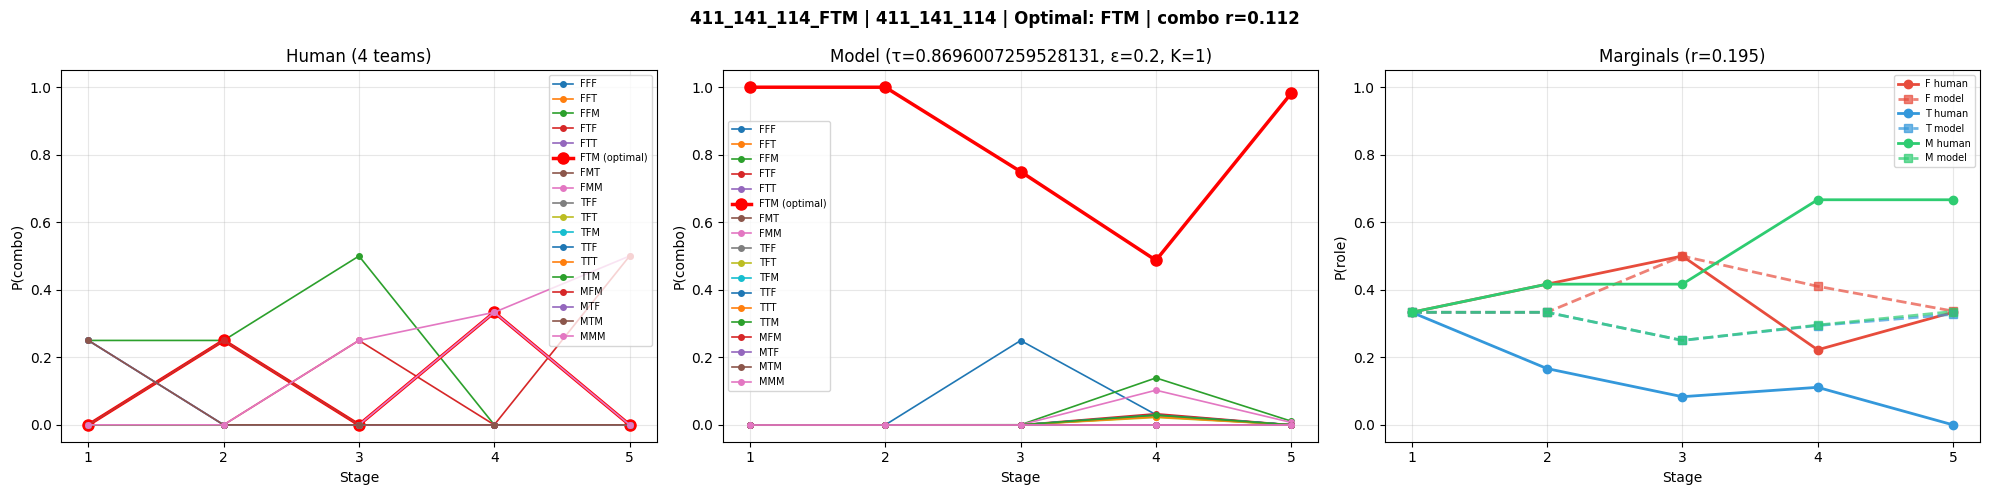

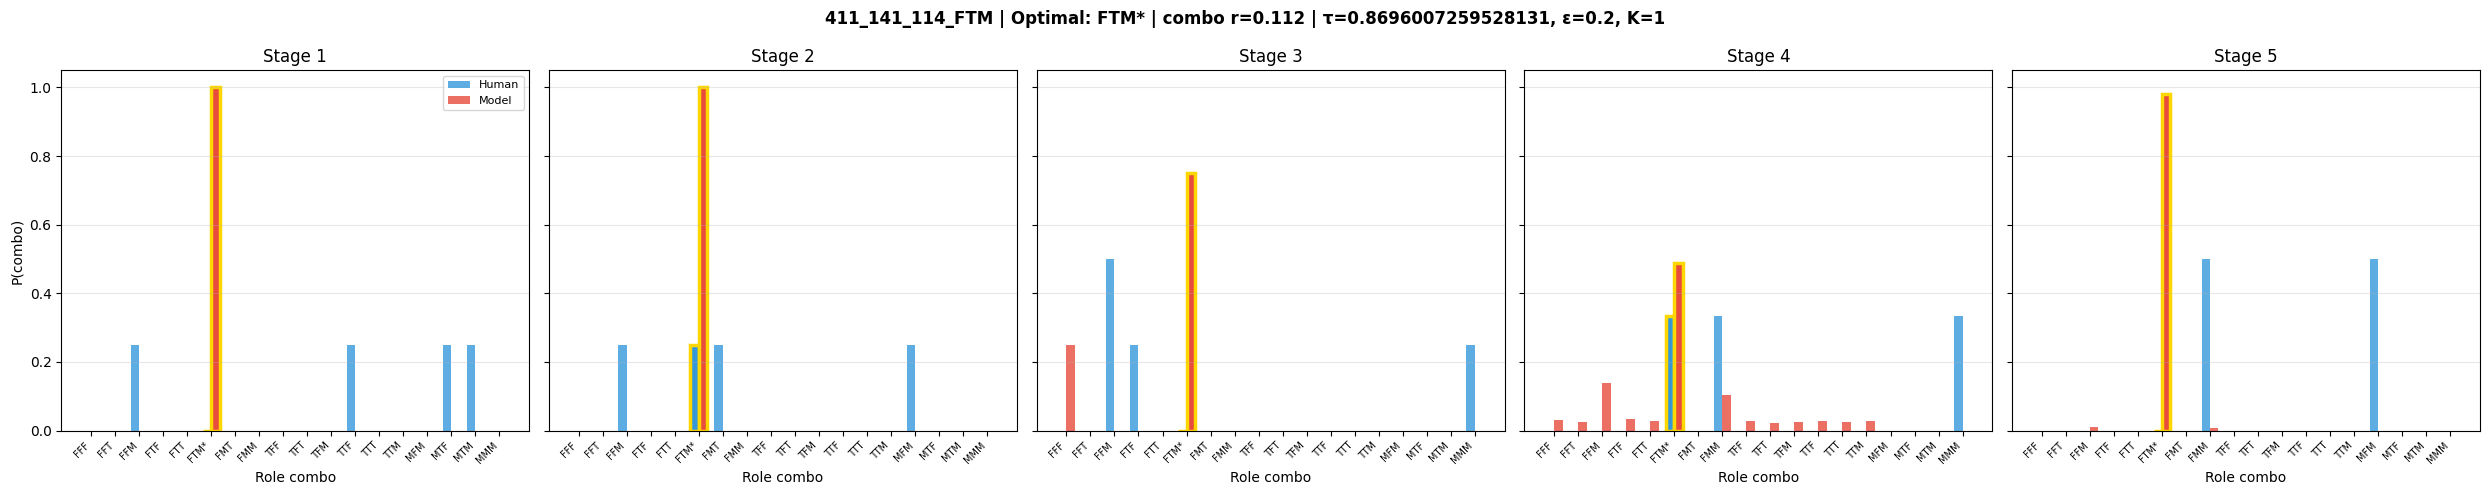

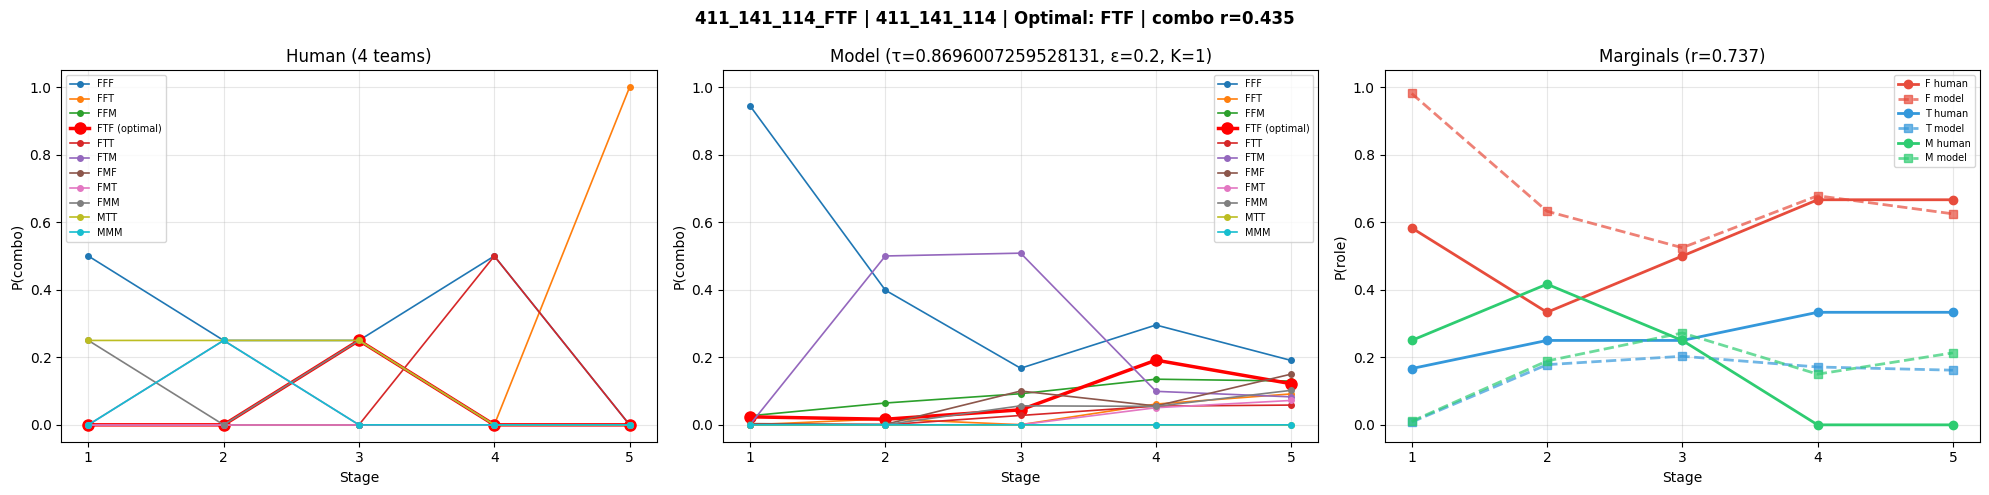

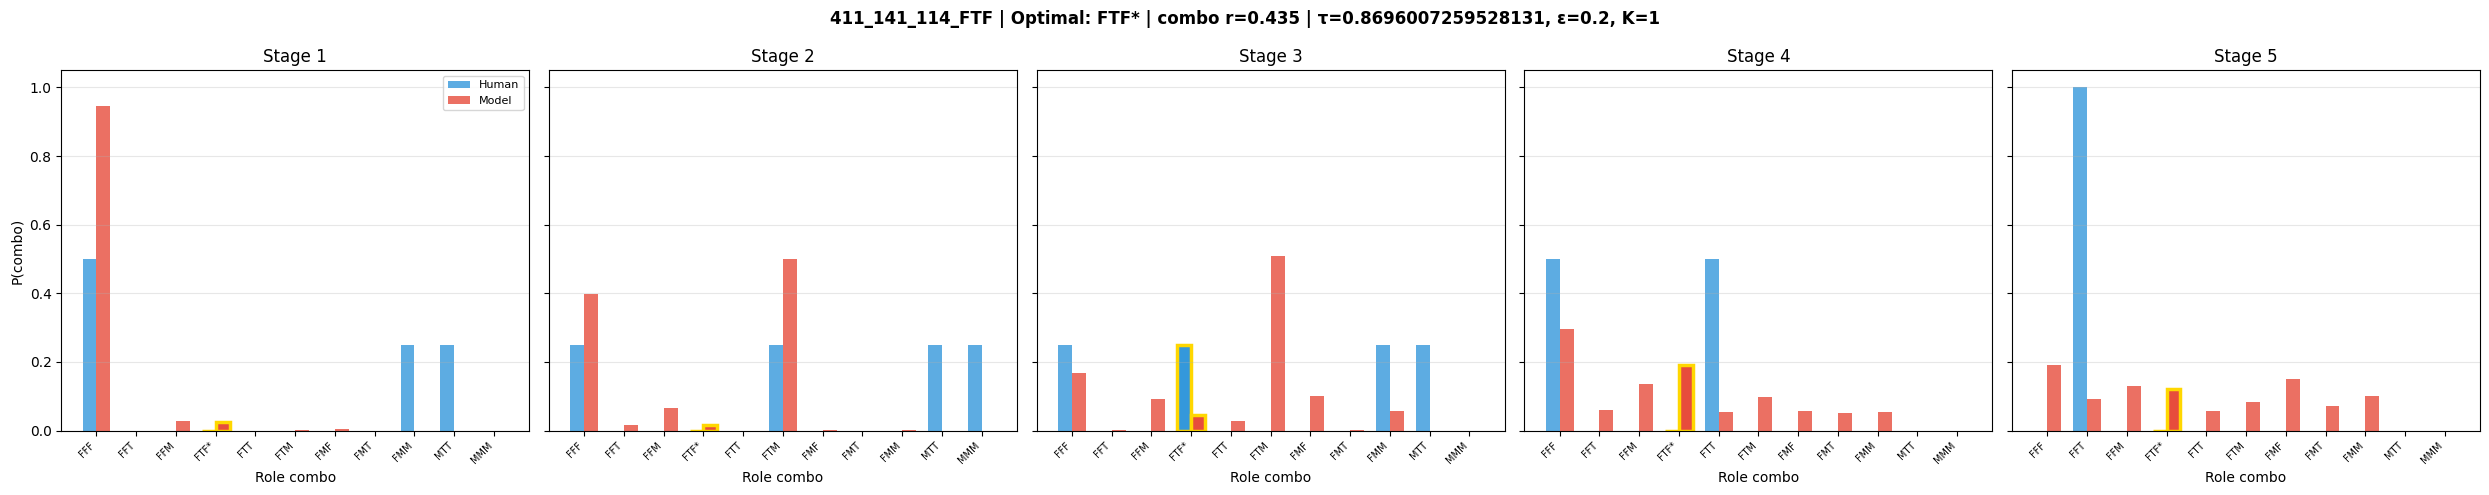

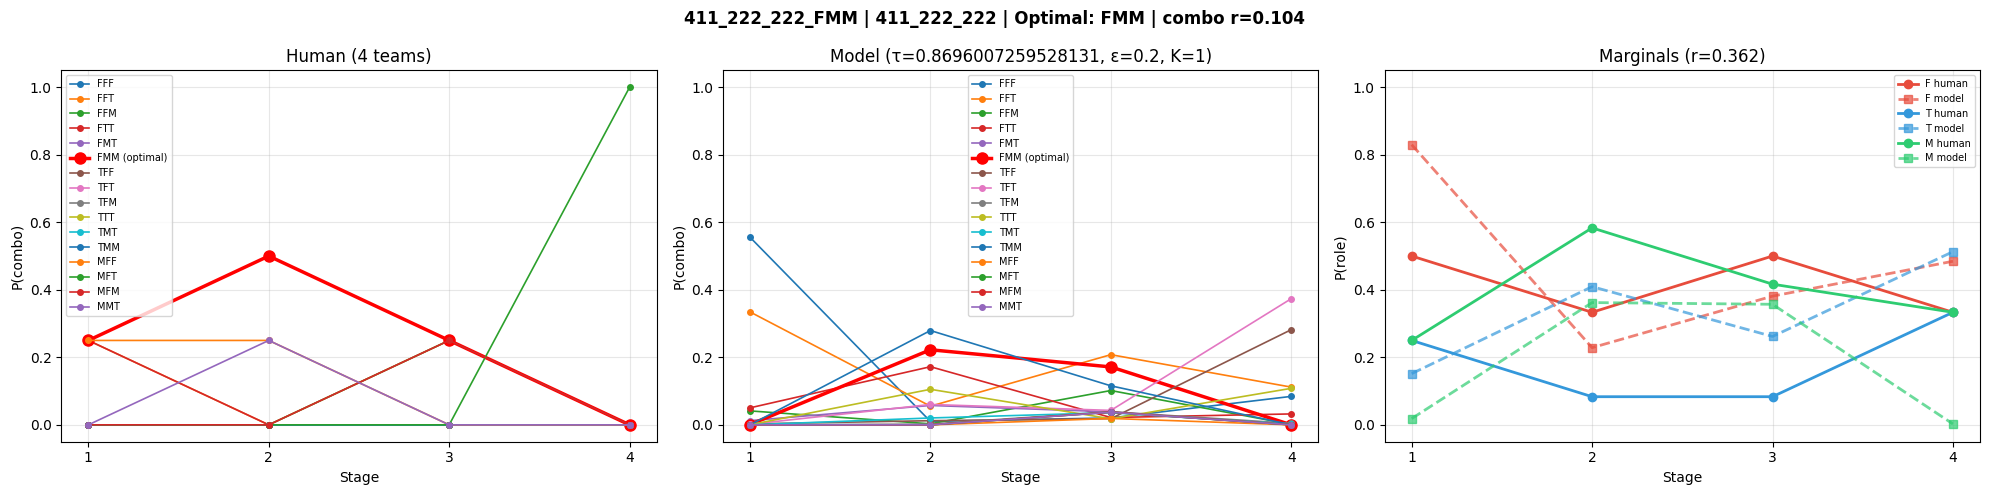

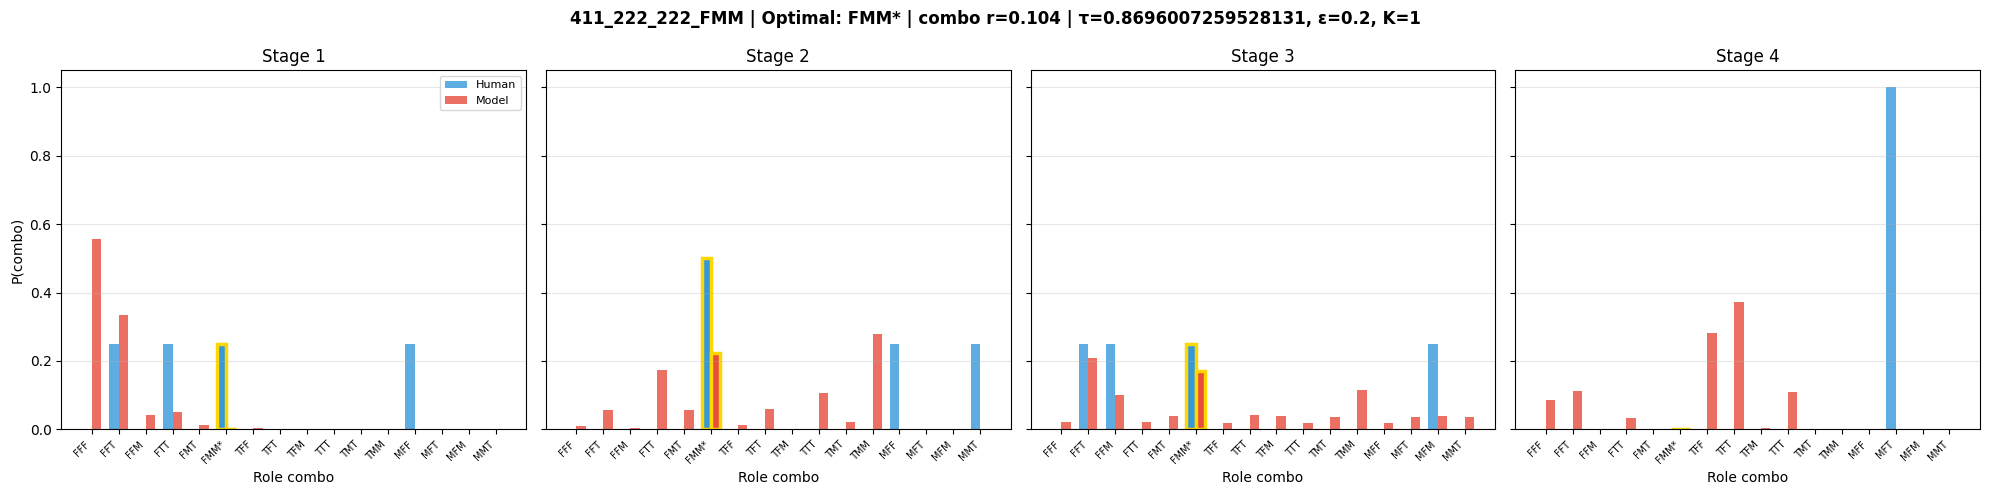

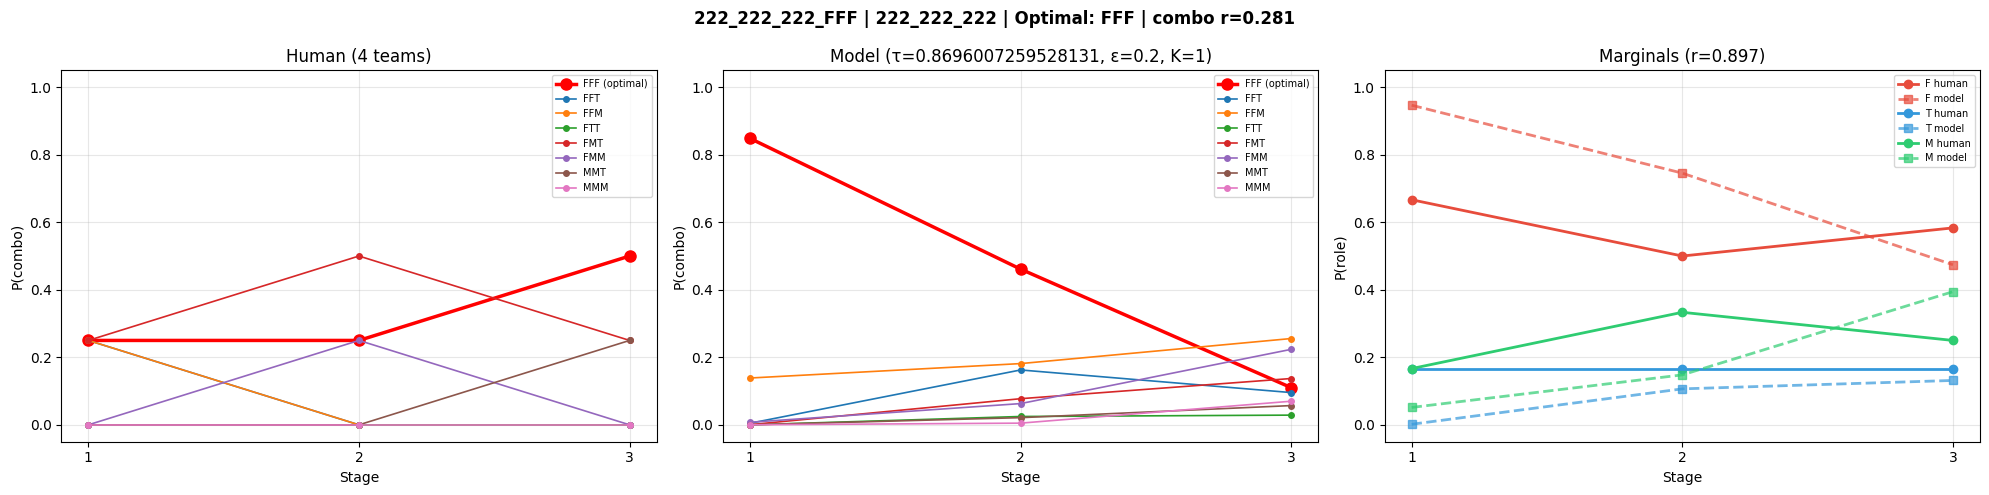

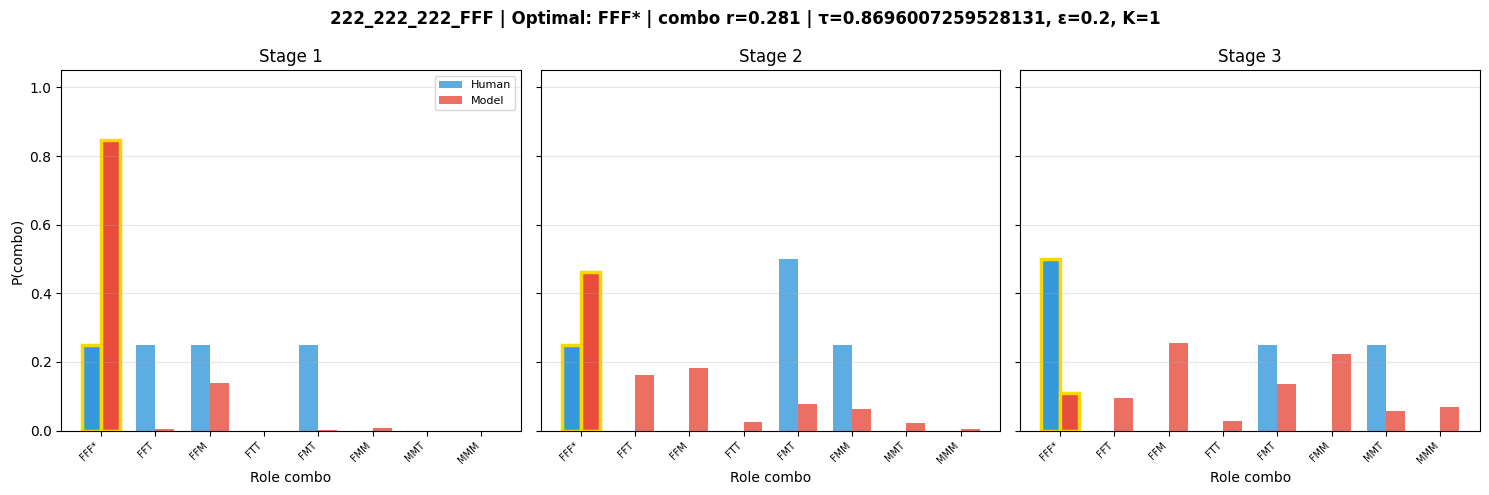

Figures saved to /Users/bhavyesh/Desktop/bayesian-role-specialization/computational_model/analysis/figures/model_comparison_online_memory


In [40]:
best_predictions = run_all_predictions(
    records, tau=best_result["tau"], prior_type=prior_type,
    epsilon=best_result["epsilon"], memory_turns=best_result["memory_turns"]
)
best_correlations = compute_pearson(best_predictions)
plot_comparison(
    best_predictions, best_correlations,
    tau=best_result["tau"], epsilon=best_result["epsilon"],
    memory_turns=best_result["memory_turns"], save=True
)
print("Figures saved to", OUTPUT_DIR)

## 5. Save Results

In [41]:
output = {
    "prior_type": prior_type,
    "best_tau": best_result["tau"],
    "best_epsilon": best_result["epsilon"],
    "best_memory_turns": best_result["memory_turns"],
    "best_combo_r": best_result["combo_r"],
    "best_marg_r": best_result["marg_r"],
    "metric_optimized": metric,
    "best_per_K": {},
    "best_correlations": best_result["correlations"],
}

for K in memory_values:
    K_results = [r for r in sweep_results if r["memory_turns"] == K]
    if K_results:
        best_K = pick_best(K_results)
        K_label = str(K) if K is not None else "all"
        output["best_per_K"][K_label] = {
            "tau": best_K["tau"],
            "epsilon": best_K["epsilon"],
            "combo_r": best_K["combo_r"],
            "marg_r": best_K["marg_r"],
        }

out_path = SCRIPT_DIR / "finetune_memory_results.json"
with open(out_path, "w") as f:
    json.dump(output, f, indent=2)
print(f"Results saved to {out_path}")

NameError: name 'json' is not defined